<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Evaluación, Selección de K y Benchmark Comparativo
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 10
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Science%20programming/10%20-%20Clustering/05_Evaluacion_Seleccion_K_y_Benchmark.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. El Reto de Evaluar un Clustering sin Etiquetas 🧭

A lo largo del módulo hemos ajustado K-Means (cuaderno 02), clustering jerárquico (cuaderno 03) y DBSCAN (cuaderno 04) casi siempre fijando de antemano un número de clústeres o un par `eps`/`min_samples` "razonable" — pero, ¿razonable según qué criterio? En clustering (aprendizaje **no supervisado**) normalmente **no existe una etiqueta verdadera** contra la cual comparar: no hay un `y_test` que nos diga si el algoritmo "acertó". Necesitamos entonces **métricas de evaluación internas**, que califiquen la calidad de una partición usando únicamente la posición de los propios puntos.

Este cuaderno de cierre del módulo cubre tres bloques estrechamente relacionados:

* **Parte 1 — Métricas de Evaluación:** Inercia/WCSS, Coeficiente de Silueta, Índice de Davies-Bouldin e Índice de Calinski-Harabasz.
* **Parte 2 — Selección del Número de Clústeres $K$:** el método del codo y el estadístico de la brecha (*Gap Statistic*).
* **Parte 3 — Benchmark Comparativo:** K-Means, clustering jerárquico y DBSCAN puestos lado a lado sobre varios datasets sintéticos de formas muy distintas, para desarrollar intuición sobre *cuándo* conviene cada algoritmo.

---
## Configuración del Entorno de Trabajo 🛠️

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys, time, urllib.request
import warnings
warnings.filterwarnings('ignore')

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (8.5, 4.5)
plt.rcParams['font.size'] = 10

def load_dataset(filename, module_folder="10 - Clustering"):
    local_path = os.path.join(os.getcwd(), "data", filename)
    if os.path.exists(local_path):
        return local_path

    parent_path = os.path.join(os.getcwd(), "..", module_folder, "data", filename)
    if os.path.exists(parent_path):
        return parent_path

    raw_url = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Science%20programming/{module_folder.replace(' ', '%20')}/data/{filename}"
    os.makedirs("data", exist_ok=True)
    target_path = os.path.join("data", filename)
    if not os.path.exists(target_path):
        urllib.request.urlretrieve(raw_url, target_path)
    return target_path

# -- Carga robusta de functions/ (local o Colab) --
import pathlib as _pl, urllib.request as _req

_BASE_RAW = (
    "https://raw.githubusercontent.com/sazuniga06/"
    "Data-Science-Programming---USTA-Tunja-Repository/main/"
    "Data%20Science%20programming/10%20-%20Clustering/"
)

def _ensure_functions_pkg(check_file='clustering_metrics.py'):
    """Busca functions/ localmente; si no existe lo descarga desde GitHub."""
    for base in [_pl.Path(os.getcwd()), _pl.Path(os.getcwd()) / '..']:
        pkg = base / 'functions'
        if (pkg / check_file).exists():
            root = str(base.resolve())
            if root not in sys.path:
                sys.path.insert(0, root)
            return
    _pl.Path('functions').mkdir(exist_ok=True)
    for fname in ['__init__.py', 'dendrogram_util.py', 'clustering_metrics.py']:
        dest = _pl.Path('functions') / fname
        if not dest.exists():
            _req.urlretrieve(_BASE_RAW + f'functions/{fname}', dest)
    cwd = os.getcwd()
    if cwd not in sys.path:
        sys.path.insert(0, cwd)
    print('  ✅ functions/ descargado desde GitHub.')

_ensure_functions_pkg('clustering_metrics.py')
from functions.clustering_metrics import wss, bss, correlation

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

file_mall = load_dataset('mall_customers.csv')
df_mall = pd.read_csv(file_mall)
X = df_mall[['Annual_Income_k', 'Spending_Score']].values
X_scaled = StandardScaler().fit_transform(X)

print("🚀 Entorno configurado exitosamente para el Módulo 10: Clustering.")
df_mall.head()

🚀 Entorno configurado exitosamente para el Módulo 10: Clustering.


,CustomerID,Gender,Age,Annual_Income_k,Spending_Score
0,1,Male,41,20,18
1,2,Female,69,29,24
2,3,Female,28,38,76
3,4,Female,66,25,25
4,5,Male,25,64,62


---
# Parte 1 — Métricas de Evaluación de Clustering 📏

## 2. Inercia / Suma de Cuadrados Intra-Cluster (WCSS)

La **inercia**, también llamada *Within-Cluster Sum of Squares* (WCSS), es la suma de las distancias al cuadrado de cada punto a su propio centroide de clúster — cuanto **menor**, más compactos son los clústeres:

$$\text{Inercia} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \lVert x_i - \mu_k \rVert^2$$

Un modelo `KMeans` ya ajustado expone este valor directamente en `kmeans_model.inertia_` — es, en la práctica, la herramienta del día a día para esta métrica.

> **Aside — "¿Cómo lo calcularía yo mismo?":** la definición anterior requiere calcular centroides explícitamente, algo natural con distancia Euclidiana pero no siempre bien definido con otras métricas (coseno, Hamming, etc. — cuaderno 01). Existe una formulación equivalente de la dispersión intra-cluster usando **solo distancias por pares**, sin pasar por un centroide: `functions/clustering_metrics.py` (incluido en este módulo) implementa exactamente esa idea con `wss(X, y_pred, metric)` (dispersión intra-cluster, *within*) y su complemento `bss(X, y_pred, metric)` (dispersión entre clústeres, *between*), además de un `correlation(X, y_pred, metric)` que compara la estructura de clústeres encontrada contra la matriz de similitud de los datos. Vale la pena leer su código fuente para entender el mecanismo — pero para uso cotidiano con K-Means y distancia Euclidiana, `kmeans_model.inertia_` sigue siendo la opción más simple y eficiente.

In [2]:
kmeans_model = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
y_pred_kmeans = kmeans_model.fit_predict(X_scaled)

print(f"Inercia (kmeans_model.inertia_): {kmeans_model.inertia_:.3f}")

# Aside: la dispersión intra-cluster calculada solo con distancias por pares
print(f"wss(X_scaled, y_pred, 'euclidean'):  {wss(X_scaled, y_pred_kmeans, 'euclidean'):.3f}")
print(f"bss(X_scaled, y_pred, 'euclidean'):  {bss(X_scaled, y_pred_kmeans, 'euclidean'):.3f}")

Inercia (kmeans_model.inertia_): 43.512
wss(X_scaled, y_pred, 'euclidean'):  1828.579
bss(X_scaled, y_pred, 'euclidean'):  78171.421


## 3. Coeficiente de Silueta (*Silhouette Score*) 👤

El **Coeficiente de Silueta (*Silhouette Score*)** es una de las métricas internas más utilizadas para evaluar la calidad de un agrupamiento. Mide qué tan cercanos están los puntos dentro de su propio clúster (**cohesión intra-cluster**) en comparación con los puntos de los clústeres vecinos más próximos (**separación inter-cluster**).

Para una observación individual $i$ perteneciente al clúster $C(i)$:

* **$a(i)$**: Distancia promedio desde el punto $i$ a todos los demás puntos de su mismo clúster:
  $$a(i) = \frac{1}{|C(i)| - 1} \sum_{j \in C(i), j \neq i} d(i, j)$$

* **$b(i)$**: Distancia promedio más pequeña desde el punto $i$ a los puntos de **cualquier otro clúster** distinto (el clúster vecino más cercano):
  $$b(i) = \min_{C_k \neq C(i)} \frac{1}{|C_k|} \sum_{j \in C_k} d(i, j)$$

El coeficiente de silueta de la observación $i$ se define como:

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$

### Interpretación del Rango $[-1, 1]$:
* **$s(i) \approx +1$**: El punto está muy cerca de los miembros de su clúster y muy lejos del clúster vecino ($a(i) \ll b(i)$). El agrupamiento es óptimo.
* **$s(i) \approx 0$**: El punto se encuentra justo en la frontera de decisión entre dos clústeres ($a(i) \approx b(i)$).
* **$s(i) < 0$**: El punto está más cerca en promedio de un clúster vecino que del suyo propio ($a(i) > b(i)$), lo que sugiere una asignación incorrecta.

> 📌 **Nota:** Si un clúster tiene un solo punto ($|C(i)| = 1$), su coeficiente de silueta se define como $0$ para evitar indeterminaciones matemáticas.

El **Silhouette Score global** es la media de $s(i)$ sobre todas las observaciones del conjunto de datos.

In [ ]:
# Ajustamos modelos de referencia para comparar las métricas
aggl_model = AgglomerativeClustering(n_clusters=5, linkage='ward').fit(X_scaled)
dbscan_model = DBSCAN(eps=0.4, min_samples=5).fit(X_scaled)

# 1. Cálculo de Silhouette Score con Scikit-Learn
print(f"Silhouette score for Agglomerative Clustering: {silhouette_score(X_scaled, aggl_model.labels_):.4f}")
print(f"Silhouette score for K-Means Clustering:         {silhouette_score(X_scaled, kmeans_model.labels_):.4f}")
print(f"Silhouette score for DBSCAN Clustering:          {silhouette_score(X_scaled, dbscan_model.labels_):.4f}")

### Visualización de Perfiles de Silueta con Yellowbrick 📊

La función global `silhouette_score` resume la calidad en un único promedio, pero oculta la distribución interna: puede haber clústeres muy compactos y otros dispersos. Para inspeccionar la silueta punto a punto utilizamos el `SilhouetteVisualizer` de **Yellowbrick**:

* Cada franja horizontal representa una muestra clasificada por clúster.
* El ancho de la franja corresponde a su coeficiente individual $s(i)$.
* La **línea punteada roja vertical** indica el *Silhouette Score* promedio global.
* Los clústeres cuyas siluetas sobrepasan la línea roja son más densos y cohesivos que el promedio.

In [ ]:
try:
    from yellowbrick.cluster import SilhouetteVisualizer, silhouette_visualizer
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "yellowbrick", "-q"])
    from yellowbrick.cluster import SilhouetteVisualizer, silhouette_visualizer

# Visualización detallada de siluetas por clúster con Yellowbrick
fig, ax = plt.subplots(figsize=(9, 5))
visualizer = SilhouetteVisualizer(kmeans_model, colors='yellowbrick', ax=ax)
visualizer.fit(X_scaled)
visualizer.show()
plt.show()

> ⚠️ **¡Atención!** El *Silhouette Score* no es el mejor índice para cualquier solución de clustering. Favorece estructuras esféricas y convexas (como K-Means); en geometrías complejas (como anillos concéntricos donde DBSCAN destaca) la silueta puede ser engañosamente baja. Consulta la [guía de evaluación de Scikit-Learn](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation) para una visión comparativa.

## 4. Índice de Davies-Bouldin (DB Index) 📉

El **Índice de Davies-Bouldin (DB)** cuantifica la similitud promedio entre cada clúster y su vecino más cercano:

$$DB = \frac{1}{K} \sum_{i=1}^{K} \max_{j \ne i} \left( \frac{\bar{d}_i + \bar{d}_j}{d(\mu_i, \mu_j)} \right)$$

donde:
* $\bar{d}_i$: distancia promedio de las observaciones del clúster $i$ a su centroide $\mu_i$ (**compacidad**).
* $d(\mu_i, \mu_j)$: distancia euclidiana entre los centroides de los clústeres $i$ y $j$ (**separación**).

> 💡 **Criterio de decisión:** **Valores más bajos indican mejor clustering** (menor dispersión intra-cluster y mayor separación entre centroides).

In [ ]:
print(f"Davies-Bouldin score for Agglomerative Clustering: {davies_bouldin_score(X_scaled, aggl_model.labels_):.4f}")
print(f"Davies-Bouldin score for K-Means Clustering:         {davies_bouldin_score(X_scaled, kmeans_model.labels_):.4f}")
print(f"Davies-Bouldin score for DBSCAN Clustering:          {davies_bouldin_score(X_scaled, dbscan_model.labels_):.4f}")

## 5. Índice de Calinski-Harabasz (Variance Ratio Criterion) 📈

El **Índice de Calinski-Harabasz (CH)** evalúa la razón entre la dispersión entre clústeres y la dispersión dentro de los clústeres:

$$CH = \frac{\text{Tr}(\mathbf{B}_k)}{\text{Tr}(\mathbf{W}_k)} \times \frac{N - K}{K - 1}$$

donde $N$ es el número total de datos y $K$ es el número de clústeres.

> 💡 **Criterio de decisión:** **Valores más altos indican mejor clustering** (clústeres densos y bien separados unos de otros).

In [ ]:
print(f"Calinski-Harabasz score for Agglomerative Clustering: {calinski_harabasz_score(X_scaled, aggl_model.labels_):.4f}")
print(f"Calinski-Harabasz score for K-Means Clustering:         {calinski_harabasz_score(X_scaled, kmeans_model.labels_):.4f}")
print(f"Calinski-Harabasz score for DBSCAN Clustering:          {calinski_harabasz_score(X_scaled, dbscan_model.labels_):.4f}")

## 6. Comparando Algoritmos con las Cuatro Métricas 🔬

Ajustamos K-Means, clustering jerárquico aglomerativo (`linkage='ward'`) y DBSCAN sobre los mismos datos escalados (`X_scaled`), y tabulamos las cuatro métricas lado a lado. La **inercia** solo tiene sentido para K-Means (es literalmente su función objetivo; ni `AgglomerativeClustering` ni `DBSCAN` la exponen), por lo que la dejamos como `NaN` para los otros dos algoritmos.

In [6]:
modelos = {
    'KMeans (k=5)': KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42),
    'Agglomerative (ward, k=5)': AgglomerativeClustering(n_clusters=5, linkage='ward'),
    'DBSCAN (eps=0.4, min_samples=5)': DBSCAN(eps=0.4, min_samples=5),
}

resultados = []
for nombre, modelo in modelos.items():
    labels = modelo.fit_predict(X_scaled)
    inercia = modelo.inertia_ if hasattr(modelo, 'inertia_') else np.nan
    resultados.append({
        'Modelo': nombre,
        'N clústeres': len(set(labels)) - (1 if -1 in labels else 0),
        'N ruido': int((labels == -1).sum()),
        'Inercia': inercia,
        'Silueta': silhouette_score(X_scaled, labels),
        'Davies-Bouldin': davies_bouldin_score(X_scaled, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_scaled, labels),
    })

pd.DataFrame(resultados).round(3)

,Modelo,N clústeres,N ruido,Inercia,Silueta,Davies-Bouldin,Calinski-Harabasz
0,KMeans (k=5),5,0,43.512,0.597,0.536,399.399
1,"Agglomerative (ward, k=5)",5,0,NaN,0.581,0.553,375.148
2,"DBSCAN (eps=0.4, min_samples=5)",2,2,NaN,0.259,0.812,38.755


Nótese que las tres métricas de comparación (silueta, Davies-Bouldin y Calinski-Harabasz) no siempre coinciden entre sí en cuál algoritmo prefieren — esto es esperable, dado que cada una pondera compacidad y separación de forma ligeramente distinta. Por eso conviene reportar **varias métricas en conjunto**, no una sola, al comparar algoritmos o configuraciones de hiperparámetros.

---
# Parte 2 — Selección del Número de Clústeres $K$ 🔢

---
## 7. Determinando el Número Óptimo de Clústeres ($K$) 🎯

En 2 o 3 dimensiones es posible identificar agrupamientos de forma visual. Sin embargo, en problemas reales de alta dimensionalidad se requieren criterios sistemáticos. A medida que incrementamos $K$, la distancia promedio intra-cluster decrece naturalmente (si cada punto tuviese su propio clúster con $K=N$, la distancia sería 0, lo cual es inútil).

Los métodos principales para seleccionar $K$ son:
1. **Método del Codo (*Elbow Method*)**
2. **Análisis de Silueta (*Silhouette Analysis*)**
3. **Criterio de Calinski-Harabasz y Davies-Bouldin**
4. **Estadístico de la Brecha (*Gap Statistic*)**
5. **Corte de Dendrograma (en Clustering Jerárquico)**

## 8. Método del Codo (*Elbow Method*) con Yellowbrick 📐

El método consiste en ajustar el modelo para un rango de valores de $K$, registrar la métrica de costo y graficarla. El valor óptimo de $K$ es el punto donde la tasa de ganancia comienza a desacelerarse (el "codo" de la curva).

La función `kelbow_visualizer` de **Yellowbrick** automatiza este proceso calculando el codo matemáticamente y mostrando el tiempo de entrenamiento.

In [ ]:
from yellowbrick.cluster import kelbow_visualizer

# 1. Método del Codo con Inercia (Distortion Score)
plt.figure(figsize=(9, 4.5))
kelbow_visualizer(KMeans(init='random', n_init='auto', random_state=109), X_scaled, k=(2, 15), timings=True)
plt.show()

### Selección de $K$ mediante Silueta y Calinski-Harabasz en Yellowbrick

También podemos evaluar la calidad cambiando el parámetro `metric` en `kelbow_visualizer`:

In [ ]:
# 2. Codo optimizando Silhouette Score (busca el valor máximo)
plt.figure(figsize=(9, 4.5))
kelbow_visualizer(KMeans(init='random', n_init='auto', random_state=109), X_scaled, k=(2, 15), metric='silhouette', timings=False)
plt.show()

# 3. Codo optimizando Calinski-Harabasz Score
plt.figure(figsize=(9, 4.5))
kelbow_visualizer(KMeans(init='random', n_init='auto', random_state=109), X_scaled, k=(2, 15), metric='calinski_harabasz', timings=False)
plt.show()

### Selección de $K$ mediante Davies-Bouldin

Como Yellowbrick no incluye Davies-Bouldin por defecto, implementamos una rutina estándar con Scikit-Learn (buscando el **mínimo** global):

In [ ]:
def get_kmeans_db_score(data, k):
    kmeans = KMeans(n_clusters=k, init='random', n_init='auto', random_state=109)
    labels = kmeans.fit_predict(data)
    return davies_bouldin_score(data, labels)

ks = list(range(2, 15))
db_scores = [get_kmeans_db_score(X_scaled, k) for k in ks]

plt.figure(figsize=(8, 4))
plt.plot(ks, db_scores, linestyle='--', marker='o', color='b')
plt.xlabel('K')
plt.ylabel('Davies-Bouldin score')
plt.title('Davies-Bouldin score vs. K (Menor es mejor)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

## 9. Estadístico de la Brecha (*Gap Statistic*) 📊

Propuesto en el trabajo clásico de Tibshirani, Walther y Hastie (*[Estimating the number of clusters in a data set via the gap statistic](https://academic.oup.com/jrsssb/article/63/2/411/7083348)*, 2001), el **Estadístico de la Brecha** formaliza la elección de $K$ eliminando la subjetividad visual del método del codo.

### Fundamento Teórico:
La dispersión intra-cluster decrece mecánicamente al aumentar $K$, aun en datos sin estructura alguna. El Gap Statistic compara la caída observada en los datos reales con la caída esperada bajo una **distribución nula de referencia** (datos generados uniformemente al azar con la misma dispersión que los originales):

$$\text{Gap}(k) = \mathbb{E}^*\{\log(W_k)\} - \log(W_k)$$

Se selecciona el menor $K$ tal que:
$$\text{Gap}(k) \ge \text{Gap}(k+1) - s_{k+1}$$

> 📦 **Librería Especializada:** La librería de Python `gap_statistic` (de Miles Granger, `pip install gap-stat`) proporciona la clase `OptimalK()`. A continuación presentamos una implementación autocontenida y compatible con NumPy/Scikit-Learn:

<Figure size 850x450 with 0 Axes>

<ErrorbarContainer object of 3 artists>

Text(0.5, 0, 'K')

Text(0, 0.5, 'Gap(K)')

Text(0.5, 1.0, 'Estadístico de la Brecha vs. K')

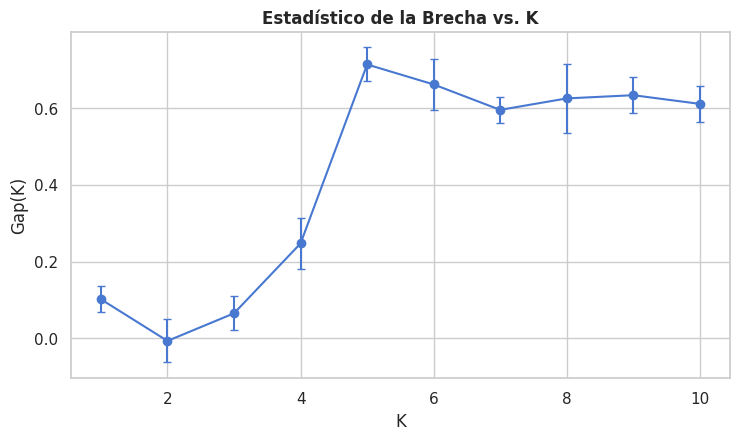

K sugerido por el estadístico de la brecha: 1


In [9]:
def gap_statistic(X, k_range, n_refs=10, random_state=0):
    rng = np.random.default_rng(random_state)
    mins, maxs = X.min(axis=0), X.max(axis=0)

    gaps, sks, log_wks = [], [], []
    for k in k_range:
        # Dispersión intra-cluster de los datos reales
        km_real = KMeans(n_clusters=k, n_init='auto', random_state=random_state).fit(X)
        log_wk = np.log(km_real.inertia_)

        # Dispersión intra-cluster promedio en n_refs datasets de referencia uniformes
        log_wk_refs = []
        for _ in range(n_refs):
            X_ref = rng.uniform(mins, maxs, size=X.shape)
            km_ref = KMeans(n_clusters=k, n_init='auto', random_state=random_state).fit(X_ref)
            log_wk_refs.append(np.log(km_ref.inertia_))

        log_wk_refs = np.array(log_wk_refs)
        gap = log_wk_refs.mean() - log_wk
        sk = log_wk_refs.std() * np.sqrt(1 + 1 / n_refs)

        gaps.append(gap)
        sks.append(sk)
        log_wks.append(log_wk)

    return np.array(gaps), np.array(sks)

k_range = list(range(1, 11))
gaps, sks = gap_statistic(X_scaled, k_range, n_refs=10, random_state=42)

plt.figure()
plt.errorbar(k_range, gaps, yerr=sks, marker='o', capsize=3)
plt.xlabel('K')
plt.ylabel('Gap(K)')
plt.title("Estadístico de la Brecha vs. K", fontweight='bold')
plt.show()

# Regla de Tibshirani et al.: el menor K tal que Gap(K) >= Gap(K+1) - s_{K+1}
k_hat = None
for i in range(len(k_range) - 1):
    if gaps[i] >= gaps[i + 1] - sks[i + 1]:
        k_hat = k_range[i]
        break

print(f"K sugerido por el estadístico de la brecha: {k_hat}")

## 10. Recordatorio: El Dendrograma También Ayuda a Elegir $K$ 🌳

Para clustering jerárquico específicamente (cuaderno 03), no hace falta recurrir a estos métodos: basta con **inspeccionar visualmente el dendrograma** y elegir una altura de corte que separe clústeres con alta disimilitud (una brecha vertical grande entre dos fusiones consecutivas) — el dendrograma es, en cierto sentido, una herramienta de selección de $K$ construida directamente en el algoritmo.

---
##### 🛠️ Práctica 1: Determinando el Número Óptimo de Clústeres para `mall_customers`

**Objetivo:** Combinar el método del codo, el pico de silueta y el estadístico de la brecha para decidir, de forma sistemática, cuántos clústeres tiene realmente el dataset de clientes — y comparar la conclusión con el $K=5$ usado por convención a lo largo del módulo.

**Instrucciones:**
1. Reutilizando `inertias` y `siluetas` ya calculados en la sección 8, identifica visualmente en qué valor de $K$ aparece el codo de inercia y en cuál aparece el pico de silueta.
2. Ejecuta `gap_statistic(X_scaled, range(1, 11))` (sección 9) y aplica la regla de Tibshirani et al. para obtener $\hat{K}$.
3. Construye una tabla (`pd.DataFrame`) que resuma, para cada método, el $K$ recomendado.
4. Responde: ¿los tres métodos coinciden en recomendar $K=5$? Si alguno difiere, ¿qué podría explicarlo, considerando cómo cada métrica define "buen clustering"?

In [ ]:
# =========================================================================
# TU SOLUCIÓN: Práctica 1 - Selección Sistemática de K
# =========================================================================

# 1. Inspecciona 'inertias' y 'siluetas' (ya calculados en la sección 8)
# k_codo = ...      # K donde ocurre el codo de inercia
# k_silueta = ks[np.argmax(siluetas)]

# 2. Estadístico de la brecha
# gaps_p1, sks_p1 = gap_statistic(X_scaled, list(range(1, 11)))
# k_gap = ...  # aplicar la regla de Tibshirani et al.

# 3. Tabla resumen
# pd.DataFrame({'Método': [...], 'K recomendado': [...]})

# 4. (Responde en una celda markdown)

<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1. K recomendado por silueta (pico máximo)
k_silueta = list(ks)[int(np.argmax(siluetas))]
# El codo de inercia se inspecciona visualmente en el gráfico de la sección 8;
# para mall_customers con 2 características suele ubicarse alrededor de K=5.
k_codo = 5

# 2. Estadístico de la brecha
gaps_p1, sks_p1 = gap_statistic(X_scaled, list(range(1, 11)), n_refs=10, random_state=42)
k_range_p1 = list(range(1, 11))
k_gap = None
for i in range(len(k_range_p1) - 1):
    if gaps_p1[i] >= gaps_p1[i + 1] - sks_p1[i + 1]:
        k_gap = k_range_p1[i]
        break

# 3. Tabla resumen
resumen_k = pd.DataFrame({
    'Método': ['Codo (inercia)', 'Pico de silueta', 'Estadístico de la brecha'],
    'K recomendado': [k_codo, k_silueta, k_gap],
})
print(resumen_k)
```

**Interpretación esperada:** el codo de inercia y el estadístico de la brecha suelen converger razonablemente cerca de $K=5$, consistente con los 5 segmentos de clientes visualmente evidentes e interpretados desde el cuaderno 02 (ingreso bajo/gasto bajo, ingreso bajo/gasto alto, etc.). El pico de silueta, en cambio, a veces favorece un $K$ más pequeño (como $K=2$ o $K=4$): la silueta premia fuertemente la separación entre clústeres, y con menos clústeres más grandes suele ser más fácil lograr una separación promedio alta, aunque se pierda granularidad de negocio útil. Esto ilustra el punto central del cuaderno: **ningún método de selección de $K$ es infalible por sí solo** — la mejor práctica es triangular varias métricas y contrastarlas siempre con el conocimiento del dominio (en este caso, el criterio de negocio de tener 5 segmentos de clientes accionables).
</details>

---
# Parte 3 — Benchmark Comparativo en Datos Sintéticos 🧪

## 11. Comparando Algoritmos de Clustering en Datos Sintéticos

Cerramos el módulo mostrando, lado a lado, cómo se comportan distintos algoritmos frente a datasets con formas deliberadamente muy distintas — el objetivo es construir intuición sobre **cuándo** conviene usar cada algoritmo, más allá de cualquier métrica numérica aislada. Este ejercicio está adaptado del ejemplo *Comparing different clustering algorithms on toy datasets* de la documentación de scikit-learn. Generamos seis datasets bidimensionales con `sklearn.datasets`:

* **`make_circles`**: dos anillos concéntricos (no convexo).
* **`make_moons`**: dos medias lunas entrelazadas (no convexo).
* **`make_blobs`**: blobs redondos y bien separados (el caso "fácil" que todo algoritmo debería resolver correctamente).
* **Blobs anisotrópicos:** los mismos blobs, tras aplicarles una transformación lineal que los estira y sesga en elipses alargadas.
* **Blobs de varianza distinta:** clústeres con dispersiones (`cluster_std`) muy diferentes entre sí.
* **`no_structure`**: puntos puramente aleatorios (`np.random.rand`) — un caso "nulo", sin ninguna estructura real de clúster.

In [10]:
from sklearn.datasets import make_circles, make_moons, make_blobs

n_samples = 1500
seed = 30

noisy_circles = make_circles(n_samples=n_samples, factor=0.5, noise=0.05, random_state=seed)
noisy_moons = make_moons(n_samples=n_samples, noise=0.05, random_state=seed)
blobs = make_blobs(n_samples=n_samples, random_state=8)

# Blobs anisotrópicos: estiramos/sesgamos blobs normales con una transformación lineal
X_b, y_b = make_blobs(n_samples=n_samples, random_state=170)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = X_b @ transformation
aniso = (X_aniso, y_b)

# Blobs con varianza distinta entre clústeres
varied = make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=170)

# Sin estructura real: puntos uniformemente aleatorios
no_structure = (np.random.RandomState(seed).rand(n_samples, 2), None)

datasets = {
    'Círculos Concéntricos': noisy_circles,
    'Medias Lunas': noisy_moons,
    'Blobs': blobs,
    'Blobs Anisotrópicos': aniso,
    'Blobs de Varianza Distinta': varied,
    'Sin Estructura': no_structure,
}

print(f"{len(datasets)} datasets sintéticos generados, cada uno con {n_samples} puntos.")

6 datasets sintéticos generados, cada uno con 1500 puntos.


Para cada dataset (previamente escalado con `StandardScaler`) ajustamos K-Means, clustering jerárquico aglomerativo con los cuatro métodos de enlace del cuaderno 03 (*average*, *single*, *complete*, *ward*) y DBSCAN — con un `eps` **sintonizado por dataset**, dado que DBSCAN es sensible a la escala/densidad particular de cada uno. Cronometramos cada ajuste y lo anotamos en la esquina de cada subgráfico.

Text(0.98, 0.02, '0.01s')

[]

[]

Text(0.5, 1.0, 'KMeans')

Text(0, 0.5, 'Círculos Concéntricos')

...

[]

Text(0.98, 0.02, '0.02s')

[]

[]

Text(0.5, 1.005, 'Benchmark Comparativo: Algoritmos de Clustering en Datasets Sintéticos')

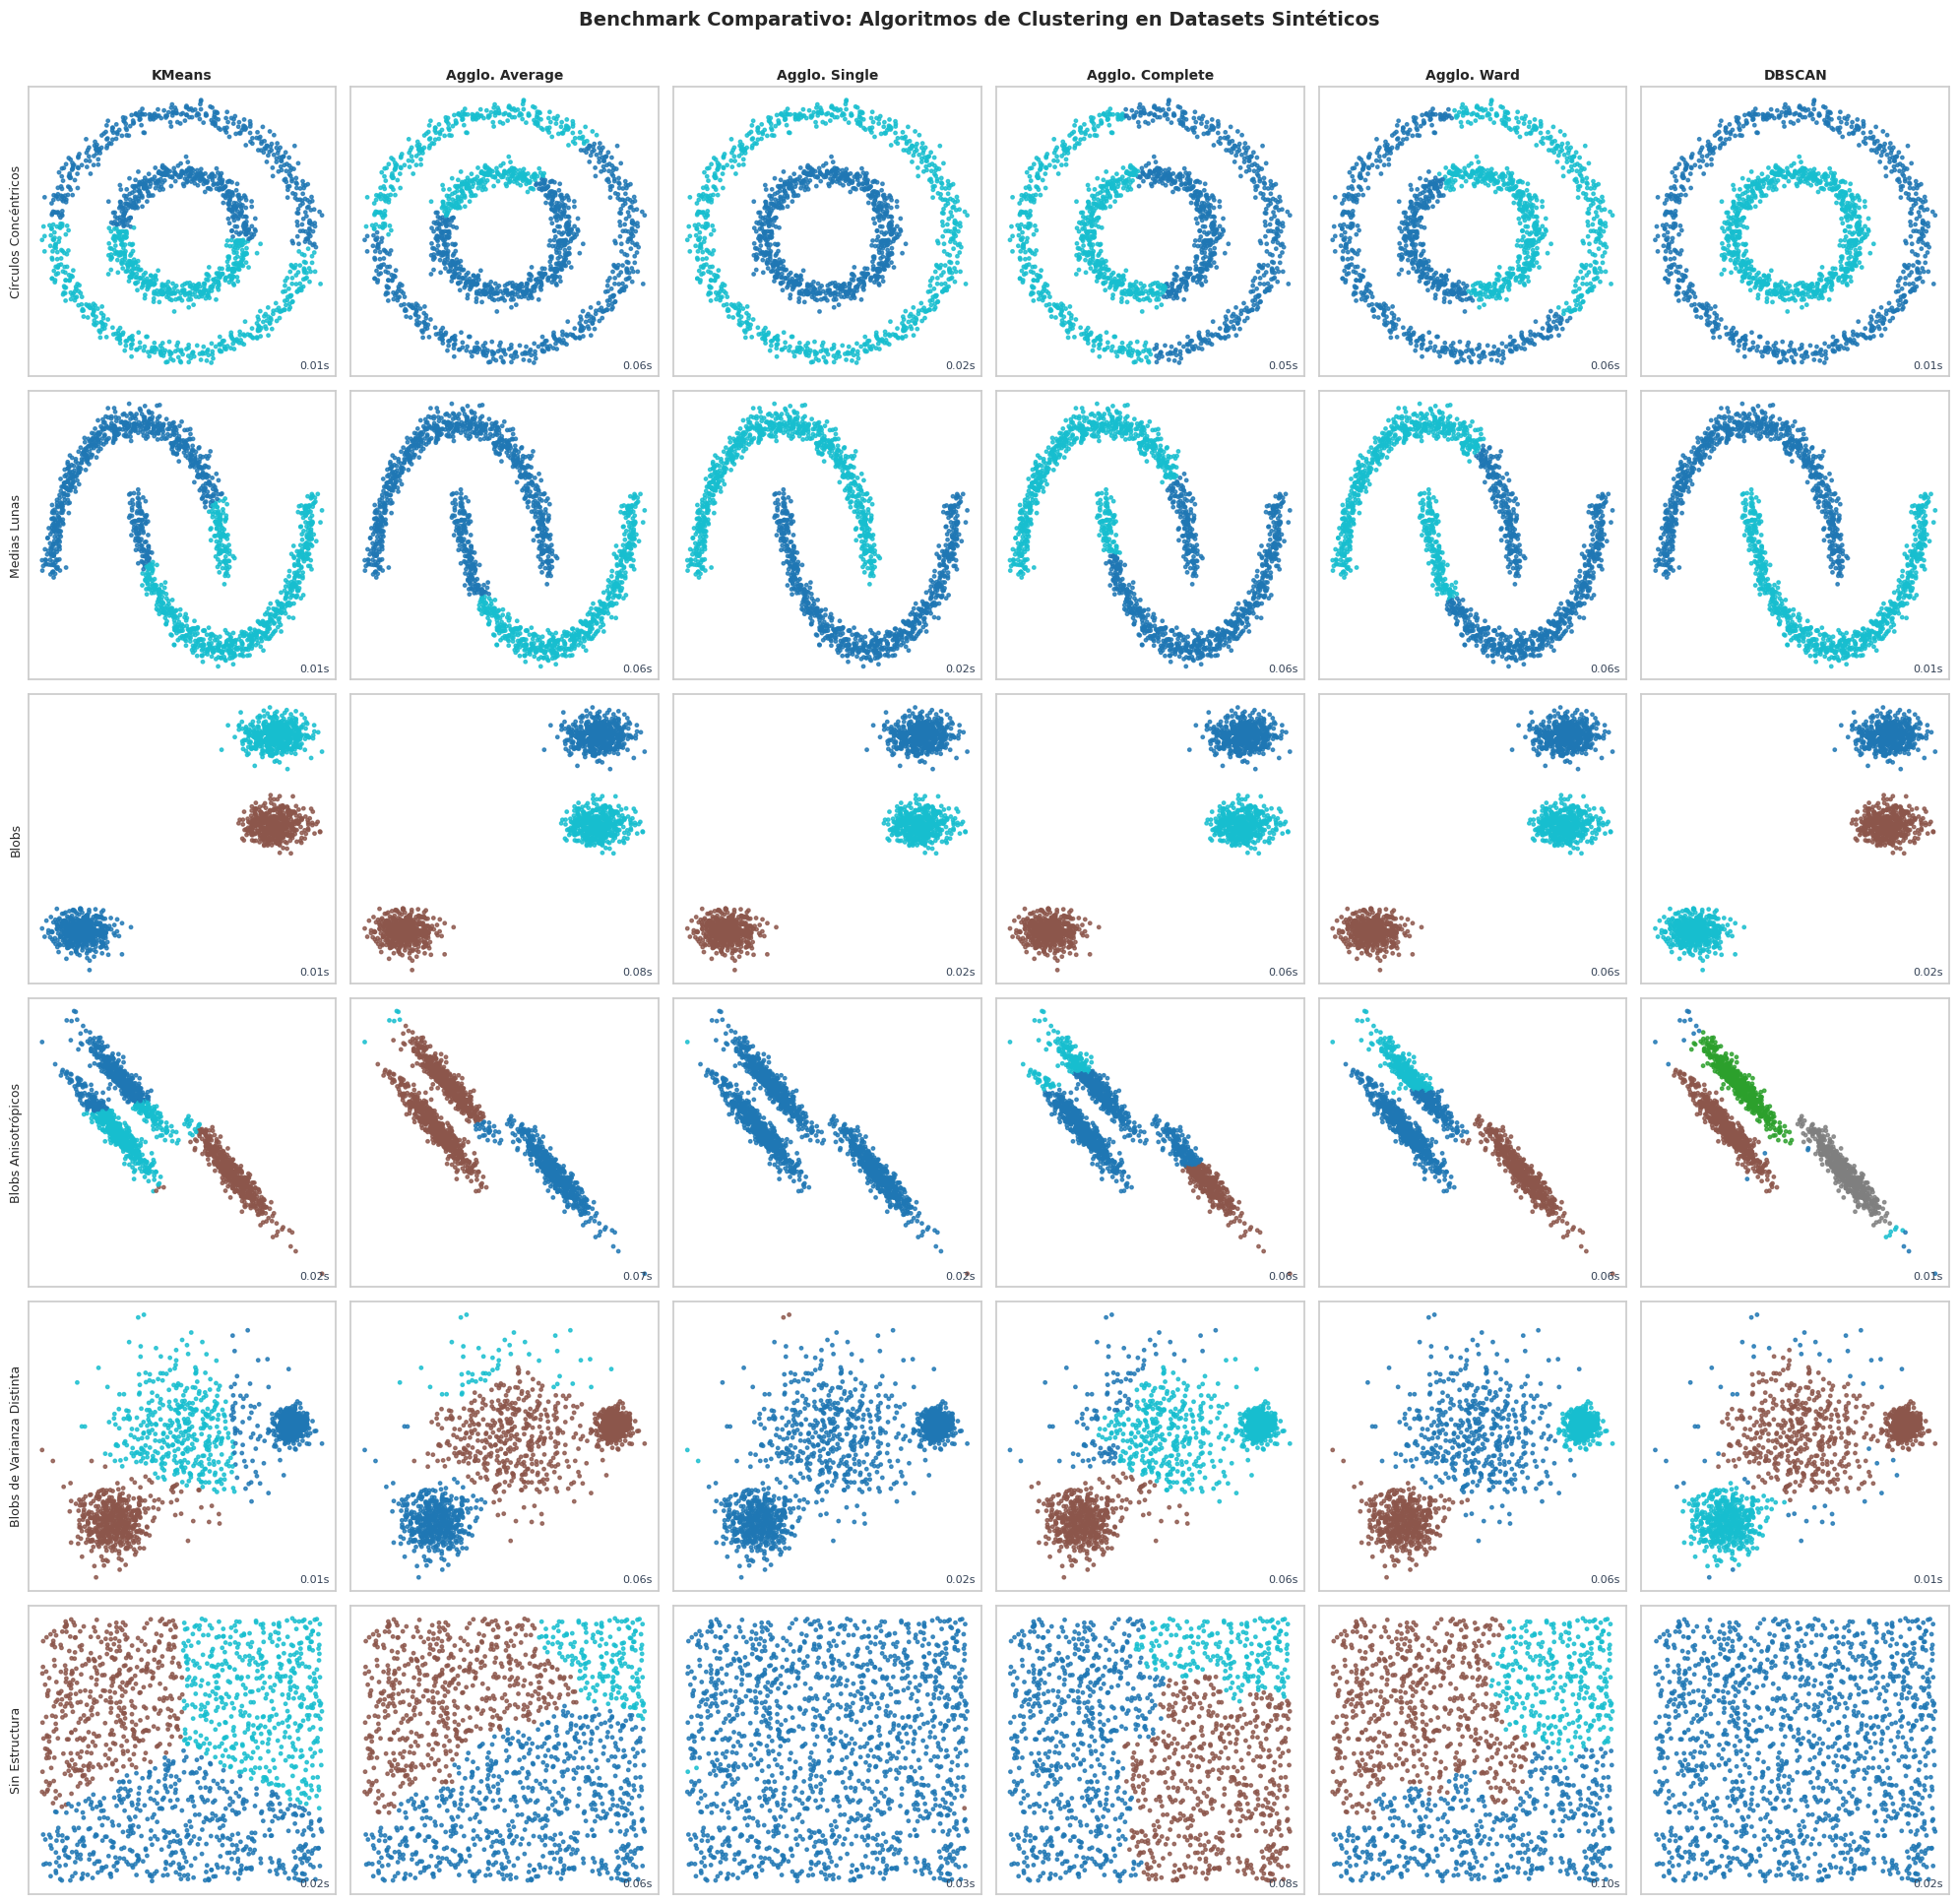

In [12]:
# eps de DBSCAN sintonizado manualmente para cada dataset (sensible a su densidad)
dbscan_eps = {
    'Círculos Concéntricos': 0.3,
    'Medias Lunas': 0.3,
    'Blobs': 0.3,
    'Blobs Anisotrópicos': 0.15,
    'Blobs de Varianza Distinta': 0.18,
    'Sin Estructura': 0.3,
}

n_clusters_default = 3  # usado por KMeans/Agglomerative en blobs/aniso/varied/no_structure
n_clusters_binario = 2  # usado en círculos y medias lunas (2 estructuras visualmente claras)

fig, axes = plt.subplots(len(datasets), 6, figsize=(20, 3.2 * len(datasets)))

for row, (nombre_ds, (X_raw, y_true)) in enumerate(datasets.items()):
    X_ds = StandardScaler().fit_transform(X_raw)
    k = n_clusters_binario if nombre_ds in ('Círculos Concéntricos', 'Medias Lunas') else n_clusters_default

    algoritmos = [
        ('KMeans', KMeans(n_clusters=k, n_init=10, random_state=0)),
        ('Agglo. Average', AgglomerativeClustering(n_clusters=k, linkage='average')),
        ('Agglo. Single', AgglomerativeClustering(n_clusters=k, linkage='single')),
        ('Agglo. Complete', AgglomerativeClustering(n_clusters=k, linkage='complete')),
        ('Agglo. Ward', AgglomerativeClustering(n_clusters=k, linkage='ward')),
        ('DBSCAN', DBSCAN(eps=dbscan_eps[nombre_ds], min_samples=5)),
    ]

    for col, (nombre_algo, modelo) in enumerate(algoritmos):
        ax = axes[row, col]
        t0 = time.time()
        labels = modelo.fit_predict(X_ds)
        elapsed = time.time() - t0

        ax.scatter(X_ds[:, 0], X_ds[:, 1], c=labels, cmap='tab10', s=6, alpha=0.8)
        ax.text(0.98, 0.02, f"{elapsed:.2f}s", transform=ax.transAxes,
                ha='right', va='bottom', fontsize=8, color='#334155')
        ax.set_xticks([])
        ax.set_yticks([])

        if row == 0:
            ax.set_title(nombre_algo, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(nombre_ds, fontsize=9)

plt.suptitle("Benchmark Comparativo: Algoritmos de Clustering en Datasets Sintéticos",
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

## 12. Lecturas Clave del Benchmark 🔑

* **En blobs redondos, todos los algoritmos funcionan bien:** cuando la estructura real ya es convexa y bien separada, K-Means, cualquier método de enlace y DBSCAN (con un `eps` razonable) coinciden en encontrarla.
* **En formas no convexas (medias lunas, círculos), K-Means y la mayoría de los métodos de enlace fallan** — *cortan* la estructura real según distancia al centroide o criterio de enlace, sin importar la forma verdadera. **DBSCAN, con un `eps` bien sintonizado, sí las recupera correctamente**, consistente con lo visto en el cuaderno 04.
* **El enlace `single` maneja sorprendentemente bien los círculos concéntricos y las medias lunas** — porque, como se explicó en el cuaderno 03, "encadena" a lo largo de la forma densa y conectada. Sin embargo, ese mismo efecto de encadenamiento lo perjudica en blobs con algo de ruido, donde termina fusionando clústeres que deberían quedar separados.
* **En el dataset "sin estructura", todo algoritmo produce igualmente *algo*** — una partición aparente, aunque no exista ningún grupo real subyacente. Esto es un recordatorio importante: que un algoritmo de clustering se ejecute exitosamente **no es evidencia** de que existan clústeres reales — siempre hay que contrastar con conocimiento de dominio y, cuando sea posible, con las métricas de evaluación de la Parte 1 (una silueta cercana a 0 en el dataset "sin estructura" sería la señal de alerta esperada).

> 🌐 **Callout de cierre:** este benchmark es deliberadamente bidimensional, solo para poder visualizarlo — la intuición de "qué forma tienen los datos" que se desarrolla en 2D **no siempre se traslada limpiamente** a datos de alta dimensionalidad, donde las distancias se comportan de forma distinta (la *maldición de la dimensionalidad*, discutida en el cuaderno 01). En dimensiones altas, confiar únicamente en la inspección visual deja de ser viable, y las métricas cuantitativas de la Parte 1 se vuelven aún más indispensables.

---
### 13. Resumen y Conclusiones del Cuaderno 05 — y Cierre del Módulo 10 📌

Este cuaderno cierra el **Módulo 10: Clustering**, así que resumimos tanto sus tres partes propias como el recorrido completo del módulo.

**De este cuaderno:**

1. **Evaluar sin Etiquetas:** la inercia (WCSS), la silueta, Davies-Bouldin y Calinski-Harabasz son las métricas internas estándar para calificar una partición sin necesitar etiquetas verdaderas — ninguna es perfecta por sí sola, y conviene reportar varias en conjunto.
2. **Elegir $K$ Sistemáticamente:** el método del codo (inercia u otra métrica) y el estadístico de la brecha ofrecen criterios cuantitativos para elegir $K$, complementando (no reemplazando) el juicio de dominio.
3. **No Existe un Algoritmo Universalmente "Mejor":** el benchmark comparativo mostró que K-Means y el clustering jerárquico dominan en estructuras convexas, mientras que DBSCAN brilla en formas arbitrarias y con presencia de ruido — la elección correcta depende de la forma real de los datos, no de una preferencia por defecto.

**Del Módulo 10 en conjunto:**

* **Cuaderno 00** presentó el clustering como aprendizaje no supervisado y sus aplicaciones.
* **Cuaderno 01** estableció las métricas de distancia y la necesidad de estandarizar antes de agrupar — una decisión que afecta a **todos** los algoritmos vistos después.
* **Cuaderno 02 (K-Means)** introdujo el clustering basado en centroides, sus estrategias de inicialización y sus limitaciones frente a formas no esféricas.
* **Cuaderno 03 (Jerárquico)** ofreció una alternativa que no exige fijar $K$ de antemano y expone sub-estructura a múltiples niveles mediante el dendrograma, a costa de un mayor costo computacional.
* **Cuaderno 04 (DBSCAN)** aportó un paradigma basado en densidad, capaz de encontrar formas arbitrarias y de separar explícitamente el ruido.
* **Este cuaderno** cerró el módulo dando las herramientas para **evaluar, comparar y elegir** entre todas las alternativas anteriores de forma rigurosa, en lugar de depender únicamente de la inspección visual.

El clustering, en definitiva, es tanto arte como ciencia: las métricas y los métodos sistemáticos de este cuaderno reducen la subjetividad, pero la interpretación final de los grupos descubiertos siempre requiere conocimiento del dominio del problema.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>